# NEUR 416 Final Project
Leif MacCarthy, Noah Villa, Rick Hanish, Emilia Cichocki

In [1]:
# Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fmin
from scipy.optimize import curve_fit

## Section 1: Creating Orientation Gratings
This section creates the orientation gratings that are used as training data, test data, and to create the psychometric curve.

### Training Data

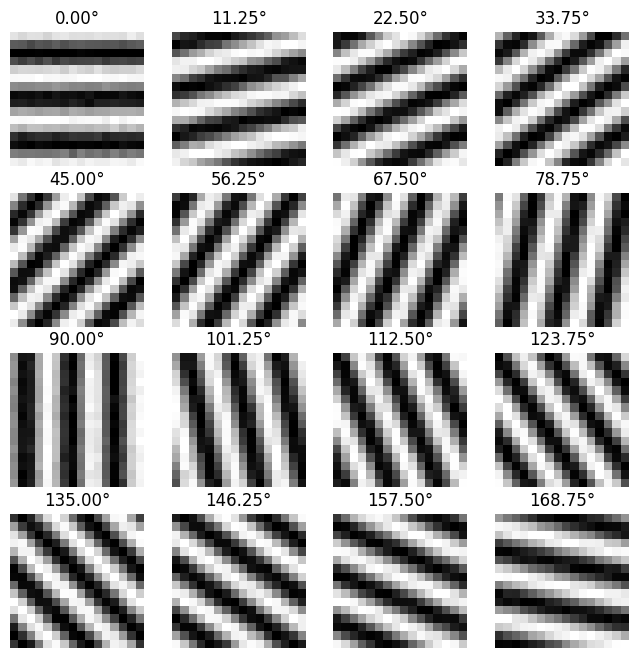

In [2]:
# Setting a seed for reproducibility
np.random.seed(42)

# Creating 16 evenly spaced orientations from 0 to 180 degrees
orientations = np.linspace(0, 180, num=16, endpoint=False)
N = 40000 # Number of training trials
H, W = 16, 16 # Defining pixel count for size and spatial frequency
num_cycles = 3
period = H / num_cycles

# Vectors for pixel coordinates
x = np.arange(H)
y = np.arange(W)
X, Y = np.meshgrid(x, y, indexing='ij')

# Defining orientations in radians for each grating with direction vectors
thetas = np.deg2rad(orientations)
cos_t = np.cos(thetas)[:, None, None]
sin_t = np.sin(thetas)[:, None, None]

# Constructing grating pattern through projection
A = 2 * np.pi * (cos_t * X[None, :, :] + sin_t * Y[None, :, :]) / period

# Calculating cosine and sine components
cosA = np.cos(A)
sinA = np.sin(A)

# Selecting and applying random orientations and phases for each image
idx_oris = np.random.choice(len(orientations), size=N, replace=True)
train_orientations = orientations[idx_oris]
phases = np.random.rand(N) * 2 * np.pi
cphi = np.cos(phases)[:, None, None]
sphi = np.sin(phases)[:, None, None]

# Identifying sine and cosine from randomly selected orientation
cosA_sel = cosA[idx_oris]
sinA_sel = sinA[idx_oris]

# Calculating orientation gratings with phase shift
train_gratings = cosA_sel * cphi - sinA_sel * sphi # NOTE: I CHANGED THIS TO BE -1 TO 1

# Adding noise by modifying each pixel and ensuring intensities are -1 to 1
noise = np.random.normal(0, 0.05, size=(N, H, W))
train_imgs = np.clip(train_gratings + noise, -1, 1)

# Selecting one of each orientation for plotting
num_oris = len(orientations)
image_id = []
for n in range(num_oris):
    idx = np.where(idx_oris == n)[0][0]
    image_id.append(idx)

# Plotting example orientations
fig, axs = plt.subplots(4, 4, figsize=(8, 8))
for i in range(4):
    for j in range(4):
        axs[i, j].imshow(train_imgs[image_id[i * 4 + j]], cmap='gray')
        axs[i, j].axis('off')
        axs[i, j].set_title(f'{orientations[idx_oris[image_id[i * 4 + j]]]:.2f}°')

### Test Data

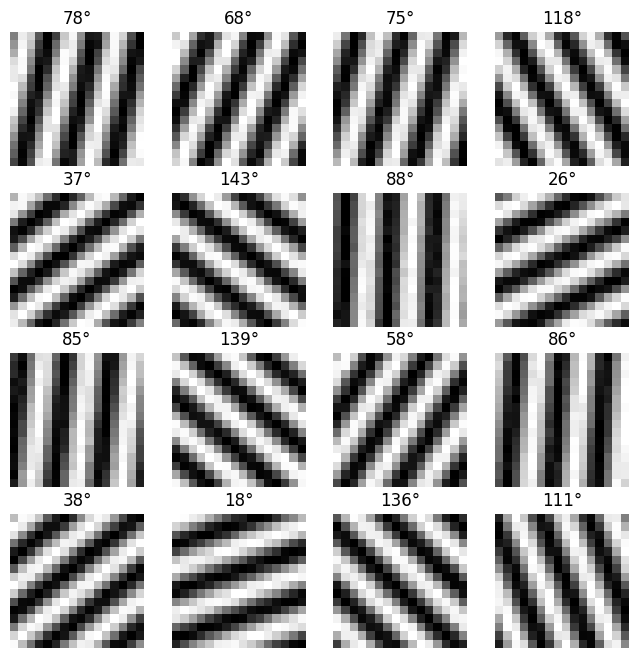

In [3]:
# Setting a seed for reproducibility
np.random.seed(42)

# Setting orientations and trial count
orientations = np.arange(0, 180)
trials = 30

# Vectors for pixel coordinates
x = np.arange(H)
y = np.arange(W)
X, Y = np.meshgrid(x, y, indexing='ij')

# Defining orientations in radians for each grating with direction vectors
thetas = np.deg2rad(orientations)
cos_t = np.cos(thetas)[:, None, None]
sin_t = np.sin(thetas)[:, None, None]

# Constructing grating pattern through projection
A = 2 * np.pi * (cos_t * X[None, :, :] + sin_t * Y[None, :, :]) / period

# Calculating cosine and sine components
cosA = np.cos(A)
sinA = np.sin(A)

# Selecting and applying random orientations and phases for each image
idx_oris = np.repeat(orientations, trials)
phases = np.random.rand(len(orientations), trials) * 2 * np.pi
cphi = np.cos(phases)[:, :, None, None]
sphi = np.sin(phases)[:, :, None, None]

# Identifying sine and cosine from randomly selected orientation
cosA_exp = cosA[:, None, :, :]
sinA_exp = sinA[:, None, :, :]

# Calculating orientation gratings with phase shift
test_gratings = cosA_exp * cphi - sinA_exp * sphi

# Adding noise by modifying each pixel and ensuring intensities are -1 to 1
noise = np.random.normal(0, 0.05, size=(len(orientations), trials, H, W))
test_imgs = np.clip(test_gratings + noise, -1, 1)

# Plotting example test stimuli
fig, axs = plt.subplots(4, 4, figsize=(8, 8))
for i in range(4):
    for j in range(4):
        orientation = np.random.randint(len(test_imgs))
        img = test_imgs[orientation, 0]
        axs[i, j].imshow(img, cmap='gray')
        axs[i, j].axis('off')
        axs[i, j].set_title(f'{orientation}°')

### Psychometric Data

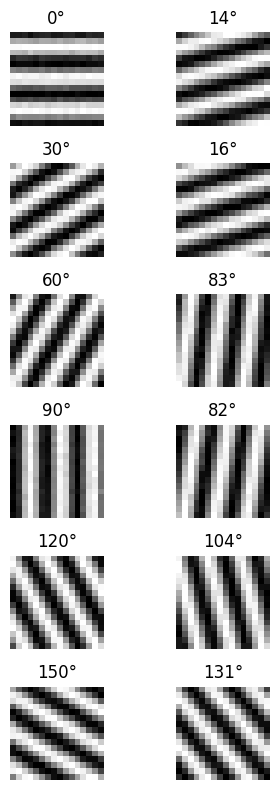

In [4]:
# Setting a seed for reproducibility
np.random.seed(42)

# Setting conditions for reference stimuli
ref_angles = np.arange(0, 180, 30)
delta_range = np.arange(-25, 26)
n_psych_trials = 30

# Determining orientation for psychometric dataset
all_oris = ref_angles[:, None] + delta_range[None, :]
thetas = np.deg2rad(all_oris)

# Vectors for pixel coordinates
x = np.arange(H)
y = np.arange(W)
X, Y = np.meshgrid(x, y, indexing='ij')

# # Calculating cosine and sine components
cos_t = np.cos(thetas)[..., None, None]
sin_t = np.sin(thetas)[..., None, None]

# Constructing grating pattern through projection
A = 2 * np.pi * (cos_t * X[None, :, :] + sin_t * Y[None, :, :]) / period

# Calculating cosine and sine components
cosA = np.cos(A)
sinA = np.sin(A)

# Selecting and applying random phases for each image
phases = np.random.rand(len(ref_angles), len(delta_range), n_psych_trials) * 2 * np.pi
cphi = np.cos(phases)[..., None, None]
sphi = np.sin(phases)[..., None, None]

# Identifying sine and cosine from selected orientation
cosA_exp = cosA[:, :, None, :, :]
sinA_exp = sinA[:, :, None, :, :]

# Calculating orientation gratings with phase shift for test gratings
test_gratings_new = cosA_exp * cphi - sinA_exp * sphi

# Determining orientation and sine/cosine components for reference set
ref_thetas = np.deg2rad(ref_angles)
cos_ref = np.cos(ref_thetas)[:, None, None]
sin_ref = np.sin(ref_thetas)[:, None, None]

# Constructing grating pattern through projection
A_ref = 2 * np.pi * (cos_ref * X + sin_ref * Y) / period

# Calculating cosine and sine components
cosA_ref = np.cos(A_ref)
sinA_ref = np.sin(A_ref)

# Identifying sine and cosine from selected orientation
cosA_ref_exp = cosA_ref[:, None, None, :, :]
sinA_ref_exp = sinA_ref[:, None, None, :, :]

# Calculating orientation gratings with phase shift for test gratings
ref_gratings = cosA_ref_exp * cphi - sinA_ref_exp * sphi

# Stacking the reference and test gratings, and verifying shape
psych_gratings = np.stack([ref_gratings, test_gratings_new], axis=2)

# Adding noise by modifying each pixel and ensuring intensities are -1 to 1
noise = np.random.normal(0, 0.05, size=(len(ref_angles), len(delta_range), 2, n_psych_trials, H, W))
psych_imgs = np.clip(psych_gratings + noise, -1, 1)

# Plotting reference and test pair examples
ref_oris = [0, 1, 2, 3, 4, 5]
fig, axs = plt.subplots(6, 2, figsize=(4, 8))
for i in range(6):
    ref_ori = ref_angles[ref_oris[i]]
    delta_ind = np.random.randint(len(delta_range))
    test_ori = ref_ori + delta_range[delta_ind]
    ref_img = psych_imgs[ref_oris[i], delta_ind, 0, 0]
    test_img = psych_imgs[ref_oris[i], delta_ind, 1, 0]
    axs[i, 0].imshow(ref_img, cmap='gray')
    axs[i, 0].axis('off')
    axs[i, 0].set_title(f'{ref_ori}°')
    axs[i, 1].imshow(test_img, cmap='gray')
    axs[i, 1].axis('off')
    axs[i, 1].set_title(f'{test_ori}°')
fig.tight_layout()
plt.show()

## Section 2: Network Structure and Training
This section constructs a small recurrent neural network and trains it using the previous orientation gratings, then checks that the learned weights resemble receptive fields.

In [5]:
# Setting general parameters
imgSz = train_imgs.shape[1]
nInputs = train_imgs.shape[1] * train_imgs.shape[2]
nOrientations = len(np.unique(train_orientations))
nOutputs = 32
nTrials = train_imgs.shape[0]
cyclesPerImage = 3
eta = 0.001
eps = 2.2204e-16

# Input assertions
assert train_imgs.ndim == 3, 'train_imgs must have dim 3.'
assert train_imgs.shape[1:] == (16, 16), 'train_imgs must be size [N x 16 x 16].'
assert train_imgs.shape[0] == 40000, 'train_imgs must contain exactly 40,000 trials.'
assert len(train_orientations) == train_imgs.shape[0], 'train_orientations length must match number of training trials.'

# Lateral inhibition parameters
sigma_E = 1
sigma_I = 4
g_E = 0.6
g_I = 0.7

In [6]:
# Building distance matrix
dist = np.zeros((nOutputs, nOutputs))
for a in range(nOutputs):
    for b in range(nOutputs):
        dist[a, b] = min(abs(a - b), nOutputs - abs(a - b))

# Computing M using rubric formula
M = g_E * np.exp(-(dist ** 2) / (2 * sigma_E ** 2)) - g_I * np.exp(-(dist ** 2) / (2 * sigma_I ** 2))

# Removing self-connection
M[np.eye(nOutputs, dtype=bool)] = 0

In [7]:
# Adding seed to ensure reproducible result
rngSeed = 150
if rngSeed is None:
    np.random.seed()
else:
    np.random.seed(rngSeed)
    
# Initializing weights
W = np.random.randn(nOutputs, nInputs) * 0.01;

# Training the network
print(f'Training for {nTrials} trials...');
for t in range(nTrials):

    # Gather stimulus
    stim = np.squeeze(train_imgs[t,:,:]);

    u = stim.flatten(order = 'F')

    # Feedforward: threshold-linear activation
    v = np.maximum(0, W @ u)

    # Lateral inhibition (single step) + ReLU
    v = np.maximum(0, v + M @ v)

    # Subtractive normalization learning rule
    sumU = np.sum(u);
    dW = v[:, None] * u[None, :] - (v[:, None] * sumU / nInputs) * np.ones((1, nInputs));
    W = W + eta * dW;

    # Bounding procedure
    # \1. Zero-mean each output neuron's weights
    W = W - np.mean(W, axis = 1, keepdims = True);

    # \2. L2 normalize each output neuron's weights
    norms = np.sqrt(np.sum(W ** 2, axis = 1, keepdims = True)) + eps;
    W = W / norms;

    # Tracking progess
    if np.mod(t, 10000) == 0:
        print(f'  Trial {t} of {nTrials} complete');

print('Training complete.');

Training for 40000 trials...
  Trial 0 of 40000 complete
  Trial 10000 of 40000 complete
  Trial 20000 of 40000 complete
  Trial 30000 of 40000 complete
Training complete.


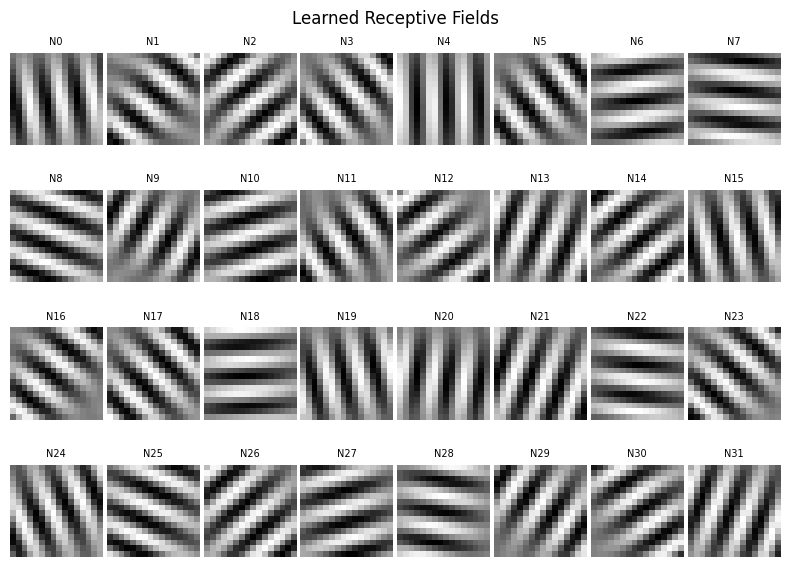

In [8]:
# Plotting receptive fields as verification
fig = plt.figure(figsize = (8, 6))
fig.suptitle('Learned Receptive Fields', y = 0.97)
for a in range(nOutputs):
    plt.subplot(4, 8, a + 1)
    weight_matrix = W[a, :].reshape(imgSz, imgSz, order = 'F')
    plt.imshow(weight_matrix, cmap = 'gray')
    plt.axis('image')
    plt.axis('off')
    plt.title(f'N{a}', fontsize = 7)
plt.tight_layout()
plt.subplots_adjust(wspace = 0.05, hspace = 0.05, top = 0.93)
plt.show()

## Section 3: Testing Efficacy of Orientation Column
This section tests the effectiveness of the RNN, first by returning tuning curves for each neuron and then by testing reference stimuli against test stimuli of different orientations to create psychometric curves and calculate the Just Noticeable Difference for each reference.

### Tuning Curves

In [9]:
# Setting parameters and data structures
nTestAngles = test_imgs.shape[0]
testAngles = np.arange(180) # Angles from 0 to 179
nTestTrials = test_imgs.shape[1] # Repetitions per angle for noise averaging
meanResponses = np.zeros((nOutputs, nTestAngles))

print('Computing tuning curves...')
for theta in range(nTestAngles):
    responses = np.zeros((nOutputs, nTestTrials))
    for trial in range(nTestTrials):
        stim = np.squeeze(test_imgs[theta, trial, :, :])
        u = stim.flatten(order = 'F')
        v = np.maximum(0, W @ u)
        v = np.maximum(0, v + M @ v)
        responses[:, trial] = v
    meanResponses[:, theta] = np.mean(responses, axis = 1)

# Fitting Gaussian to each neuron's tuning curve (finding peak and fitting around for circular data)
prefOrient = np.zeros((nOutputs, 1))
tuningWidth = np.zeros((nOutputs, 1))

for a in range(nOutputs):
    resp = meanResponses[a, :]

    # Use circular statistics to find preferred orientation (double angles to handle 0-180 wraparound)
    angles_rad = (np.pi / 180) * (testAngles * 2)
    sumSin = np.sum(resp * np.sin(angles_rad))
    sumCos = np.sum(resp * np.cos(angles_rad))
    prefAngle2 = np.arctan2(sumSin, sumCos)
    prefOrient[a] = (180/np.pi) * (prefAngle2) / 2
    if prefOrient[a] < 0:
        prefOrient[a] = prefOrient[a] + 180

    # Fit Gaussian for tuning width (shift responses so peak is centered)
    peakIdx = int(np.round(prefOrient[a] % 180).item() + 1)
    shiftedResp = np.roll(resp, 90 - peakIdx + 1)
    xFit = np.arange(-89, 91)
    yFit = shiftedResp.flatten()

    # Gaussian
    def gaussFun(p):
        return np.sum((p[0] * np.exp(-((xFit - p[1]) / (abs(p[2]) + eps)) ** 2) - yFit) ** 2)

    p0 = np.array([yFit.max(), 0, 20]) # Initial guess (amplitude, center, width)

    try:
        pFit = fmin(gaussFun, p0, disp=False)
        tuningWidth[a] = abs(pFit[2] / np.sqrt(2))

    except:
        tuningWidth[a] = np.nan

# Printing results
print(f'Tuning curve results:')
print(f"{'Neuron':<10} {'Pref Orient (deg)':<20} {'Tuning Width (deg)':<20}")
for a in range(nOutputs):
    print(f'{a:<10d} {prefOrient[a].item():<20.1f} {tuningWidth[a].item():<20.1f}')

Computing tuning curves...
Tuning curve results:
Neuron     Pref Orient (deg)    Tuning Width (deg)  
0          97.7                 8.3                 
1          140.7                12.5                
2          36.8                 9.2                 
3          129.9                11.4                
4          91.1                 8.5                 
5          127.6                10.3                
6          6.2                  8.7                 
7          175.2                8.3                 
8          161.8                7.9                 
9          61.6                 11.8                
10         15.4                 8.7                 
11         124.4                12.4                
12         36.2                 10.6                
13         68.9                 8.9                 
14         39.7                 10.5                
15         102.2                8.3                 
16         143.6                11.5              

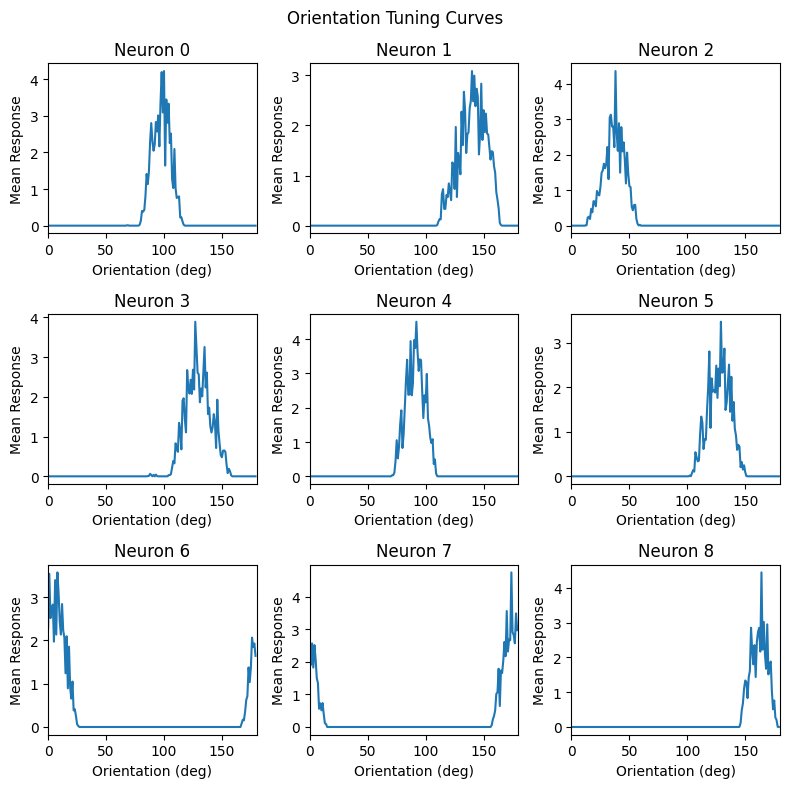

In [10]:
fig = plt.figure(figsize = (8, 8))
fig.suptitle('Orientation Tuning Curves')
nPlot = min(9, nOutputs)
for i in range(0, nPlot):
    plt.subplot(3, 3, i+1)
    plt.plot(testAngles, meanResponses[i, :])
    plt.xlabel('Orientation (deg)')
    plt.ylabel('Mean Response')
    plt.title(f'Neuron {i}')
    plt.xlim(0, 180)
plt.tight_layout()
plt.show()

### Psychometric Curves and JND

In [11]:
# Setting variables for psychometric curves
refOrients = [0, 30, 60, 90, 120, 150] # Reference orientations
deltaRange = np.arange(-25, 26) # Test offsets in degrees
nPsychTrials = psych_imgs.shape[3] # Trials per comparison

# Store psychometric data
psychData = np.zeros((len(refOrients), len(deltaRange)))

# Calculating curves
print('Computing psychometric curves...')
for ri in range(len(refOrients)):
    refTheta = refOrients[ri]
    print(f'  Reference orientation: {refTheta} deg')

    for di in range(len(deltaRange)):
        delta = deltaRange[di]
        testTheta = (refTheta + delta) % 180
        nHigher = 0
        
        for trial in range(nPsychTrials):
            # Generating and decoding reference stimulus
            stimRef = np.squeeze(psych_imgs[ri, di, 0, trial, :, :])
            uRef = stimRef.flatten(order = 'F')
            vRef = np.maximum(0, W @ uRef)
            vRef = np.maximum(0, vRef + M @ vRef)

            # Population vector decoding for reference
            thetaDecRef = 0.5 * np.arctan2(np.sum(vRef * np.sin((np.pi / 180) * (2 * prefOrient)).flatten()), np.sum(vRef * np.cos((np.pi / 180) * (2 * prefOrient)).flatten()))
            thetaDecRef = (180/np.pi) * thetaDecRef

            if thetaDecRef < 0:
                thetaDecRef = thetaDecRef + 180

            # Generating and decoding test stimulus
            stimTest = np.squeeze(psych_imgs[ri, di, 1, trial, :, :])
            uTest = stimTest.flatten(order = 'F')
            vTest = np.maximum(0, W @ uTest)
            vTest = np.maximum(0, vTest + M @ vTest)

            # Population vector decoding for test
            thetaDecTest = 0.5 * np.arctan2(np.sum(vTest * np.sin((np.pi / 180) * (2 * prefOrient)).flatten()), np.sum(vTest * np.cos((np.pi / 180) * (2 * prefOrient)).flatten()))
            thetaDecTest = (180/np.pi) * thetaDecTest

            if thetaDecTest < 0:
                thetaDecTest = thetaDecTest + 180

            # Comparing circular differences
            diff_decoded = thetaDecTest - thetaDecRef
            diff_decoded = (diff_decoded + 90) % 180 - 90

            if diff_decoded > 0:
                nHigher += 1
        
        psychData[ri, di] = nHigher / nPsychTrials * 100

Computing psychometric curves...
  Reference orientation: 0 deg
  Reference orientation: 30 deg
  Reference orientation: 60 deg
  Reference orientation: 90 deg
  Reference orientation: 120 deg
  Reference orientation: 150 deg


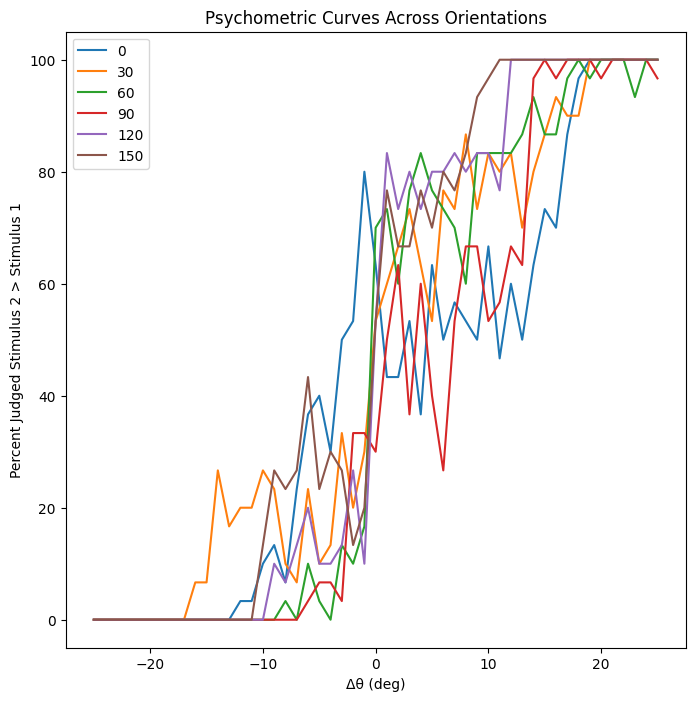

In [12]:
# Plotting the psychometric curves
fig = plt.figure(figsize = (8, 8))
plt.title('Psychometric Curves Across Orientations')
for ri in range(len(refOrients)):
    plt.plot(deltaRange, psychData[ri, :], label=f'{refOrients[ri]}°')
plt.xlabel(f'\u0394\u03B8 (deg)')
plt.ylabel('Percent Judged Stimulus 2 > Stimulus 1')
plt.legend(refOrients)

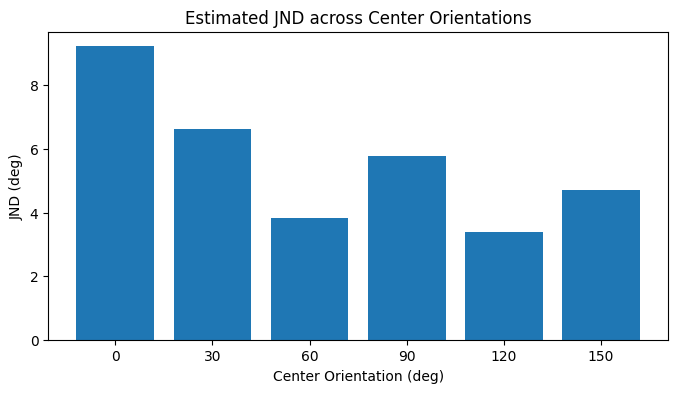

JND Results:
Reference (deg)      JND (deg)      
0                    9.22           
30                   6.64           
60                   3.84           
90                   5.77           
120                  3.38           
150                  4.71           


In [13]:
# Calculating JND and setting the initial matrix
JND = np.zeros((len(refOrients), 1))

# Defining a sigmoid function
def sigmoid(x, a, b):
    return 1 / (1 + np.exp(-a * (x - b)))

# Fitting the sigmoids and determining the 75th and 25th percentile value
for ri in range(len(refOrients)):
    curve = psychData[ri, :] / 100 # Normalize to (0, 1)
    p0 = [0.5, 0] # Initial guess
    # Attempting to fit a sigmoid
    try:
        pFit, _ = curve_fit(sigmoid, deltaRange, curve, p0 = p0, bounds=([0.01, -30], [5, 30]))
        a, b = pFit
        x75 = b + np.log(3) / a
        x25 = b - np.log(3) / a
        JND[ri] = (x75 - x25) / 2
    # Fallback through interpolation
    except RuntimeError:
        idx75 = np.where(curve >= 0.75)[0]
        idx25 = np.where(curve >= 0.25)[0]
        if len(idx75) > 0 and len(idx25) > 0:
             JND[ri] = (deltaRange[idx75] - deltaRange[idx25]) / 2
        else:
             JND[ri] = np.nan

# Plotting JND
plt.figure(figsize = (8, 4))
orients = np.arange(len(refOrients))
plt.bar(orients, JND.flatten())
plt.xticks(orients, refOrients)
plt.xlabel('Center Orientation (deg)')
plt.ylabel('JND (deg)')
plt.title('Estimated JND across Center Orientations')
plt.show()

# Printing results
print('JND Results:')
print(f"{'Reference (deg)': <20} {'JND (deg)': <15}")
for ri in range(len(refOrients)):
    print(f"{refOrients[ri]: <20} {JND[ri].item(): <15.2f}")